In [1]:
# import pandas as pd
# df = pd.read_csv("../../datasets/arabic_poetry_dataset/Arabic_Poetry_Dataset.csv")

In [2]:
import pandas as pd
df = pd.read_csv("../../datasets/arapoems_dataset/AraPoems_Dataset.csv")

In [29]:
import pandas as pd
from tashaphyne.stemming import ArabicLightStemmer
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,MaxAbsScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [4]:
verses = df["first_hemistich"]+" "+df["second_hemistich"]

In [5]:
verses

0              إيها جداب سيد الأعراب يا معدن الطعان والضراب
1              يا طيب الأحساب والأنساب قم لي مقام سيدي شهاب
2           بالعزم والحزم وبالعذاب شمر وقم يا ويك في النقاب
3                                                       NaN
4               إن الجنود حثها طلابها والأرقميون فذا شهابها
                                 ...                       
2090902            تروح كأنها مما أصابت معلقة بأحقيها الدلي
2090903        وكل مكارم الأخلاق صارت إليه همتي وبه اكتسابي
2090904     بأنا قد قتلنا الخير قرطا وجلنا في سراة بني نمير
2090905     إذا اكتنفا بضرهما سقيما يعادى الداء ليس له مقيت
2090906    ابت لي عفتي وأبى بلائي وأخذي الحمد بالثمن الربيح
Length: 2090907, dtype: object

In [6]:
df_sampled = pd.DataFrame({"qafiyeh" : df["قافية"], "verses" : verses})

In [7]:
df_sampled

,qafiyeh,verses
0,ب,إيها جداب سيد الأعراب يا معدن الطعان والضراب
1,ب,يا طيب الأحساب والأنساب قم لي مقام سيدي شهاب
2,ب,بالعزم والحزم وبالعذاب شمر وقم يا ويك في النقاب
3,ب,NaN
4,ب,إن الجنود حثها طلابها والأرقميون فذا شهابها
...,...,...
2090902,ي,تروح كأنها مما أصابت معلقة بأحقيها الدلي
2090903,ب,وكل مكارم الأخلاق صارت إليه همتي وبه اكتسابي
2090904,ر,بأنا قد قتلنا الخير قرطا وجلنا في سراة بني نمير
2090905,ت,إذا اكتنفا بضرهما سقيما يعادى الداء ليس له مقيت


In [8]:
df_sampled = df_sampled.dropna()

In [9]:
# df_sampled = df_sampled.groupby('qafiyeh').head(1000)

In [10]:
df_sampled

,qafiyeh,verses
0,ب,إيها جداب سيد الأعراب يا معدن الطعان والضراب
1,ب,يا طيب الأحساب والأنساب قم لي مقام سيدي شهاب
2,ب,بالعزم والحزم وبالعذاب شمر وقم يا ويك في النقاب
4,ب,إن الجنود حثها طلابها والأرقميون فذا شهابها
5,ب,مقدامها طعانها ضرابها زعيمها فارسها غلابها
...,...,...
2090902,ي,تروح كأنها مما أصابت معلقة بأحقيها الدلي
2090903,ب,وكل مكارم الأخلاق صارت إليه همتي وبه اكتسابي
2090904,ر,بأنا قد قتلنا الخير قرطا وجلنا في سراة بني نمير
2090905,ت,إذا اكتنفا بضرهما سقيما يعادى الداء ليس له مقيت


In [33]:
df_sampled1 = df_sampled.groupby('qafiyeh').head(30)

In [12]:
# vectorizer = TfidfVectorizer(ngram_range=(1,10))
# X = vectorizer.fit_transform(df_sampled1["verses"])

In [13]:
# X_train, X_test, y_train, y_test = train_test_split(X, df_sampled1["qafiyeh"], test_size=0.2, random_state=42)

In [14]:
# df_sampled1

In [15]:
# clf = Pipeline([
#     ('scaler', MaxAbsScaler()),
#     ('clf', MultinomialNB()),
# ])

# clf.fit(X_train, y_train)

In [16]:
# accuracy = clf.score(X_train, y_train)
# print(f"Train Accuracy: {accuracy * 100:.2f}%")
# accuracy = clf.score(X_test, y_test)
# print(f"Test Accuracy: {accuracy * 100:.2f}%")

In [17]:
# y_pred = clf.predict(X_test)

# ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
# plt.title('Naive Bayes Confusion Matrix')
# plt.show()

In [18]:
# scaler = MaxAbsScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)


# svm_clf = svm.SVC(kernel='linear', C=0.8, gamma='scale')

# # 5. Train the model
# svm_clf.fit(X_train_scaled, y_train)

# # 6. Make predictions
# y_pred = svm_clf.predict(X_test_scaled)

# # 7. Evaluate the model
# accuracy = accuracy_score(y_test, y_pred)
# print(f'Test Accuracy: {accuracy:.2%}')


In [19]:
import numpy as np
import tensorflow as tf
from transformers import AutoTokenizer, AutoModel
import torch

class EmbeddingGenerator:
    """
    Generate embeddings for Arabic texts
    """
    def __init__(self, model_name="../../pre_trained_models/akhooli"):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.tokenizer.pad_token = self.tokenizer.eos_token
        self.model = AutoModel.from_pretrained(model_name)
        self.model.eval()
        self.embedding_dim = 768
    
    def get_sentence_embedding(self, text, pooling='cls'):
        """
        Get embedding for a single sentence
        """
        inputs = self.tokenizer(
            text,
            return_tensors='pt',
            padding=True,
            truncation=True,
            # max_length=128
        )
        
        with torch.no_grad():
            outputs = self.model(**inputs)
        
        if pooling == 'mean':
            embedding = outputs.last_hidden_state.mean(dim=1).numpy()[0]
        elif pooling == 'cls':
            embedding = outputs.last_hidden_state[:, 0, :].numpy()[0]
        
        return embedding
    
    def get_batch_embeddings(self, texts, pooling='mean'):
        """
        Get embeddings for multiple sentences
        Returns: numpy array of shape (n_samples, embedding_dim)
        """
        embeddings = []
        for text in texts:
            emb = self.get_sentence_embedding(text, pooling)
            embeddings.append(emb)
        
        return np.array(embeddings)

2026-04-11 23:50:02.083435: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-11 23:50:02.799613: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-11 23:50:03.768929: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/hussam/python_envs/complete_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWa

In [20]:
eg = EmbeddingGenerator()

Some weights of the model checkpoint at ../../pre_trained_models/akhooli were not used when initializing GPT2Model: ['lm_head.weight']
- This IS expected if you are initializing GPT2Model from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing GPT2Model from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [34]:
df_sampled1

,qafiyeh,verses
0,ب,إيها جداب سيد الأعراب يا معدن الطعان والضراب
1,ب,يا طيب الأحساب والأنساب قم لي مقام سيدي شهاب
2,ب,بالعزم والحزم وبالعذاب شمر وقم يا ويك في النقاب
4,ب,إن الجنود حثها طلابها والأرقميون فذا شهابها
5,ب,مقدامها طعانها ضرابها زعيمها فارسها غلابها
...,...,...
2072390,أ,هنيئا بعود وهو أحمد عند من هواه نظيري سورة الح...
2072391,أ,فلا تعذلوني إنما اسمي هانئ لأهنأ لا أنفك دهري ...
2072392,أ,فأحمد إما يقتضي الحمد مقتض وأشكر ألطافا لذي ال...
2072393,أ,فإن أنا أمسى باب شكري مرتجى وكنت كمن أضحى حقير...


In [35]:
embeddings = eg.get_batch_embeddings(df_sampled1["verses"])

In [40]:
X_train, X_test, y_train, y_test = train_test_split(embeddings, df_sampled1["qafiyeh"], test_size=0.1, random_state=42)

In [43]:
clf = Pipeline([
    ('scaler', MinMaxScaler()),
    ('clf', MultinomialNB()),
])

clf.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()), ('clf', MultinomialNB())])

In [44]:
accuracy = clf.score(X_train, y_train)
print(f"Train Accuracy: {accuracy * 100:.2f}%")
accuracy = clf.score(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Train Accuracy: 75.36%
Test Accuracy: 34.41%


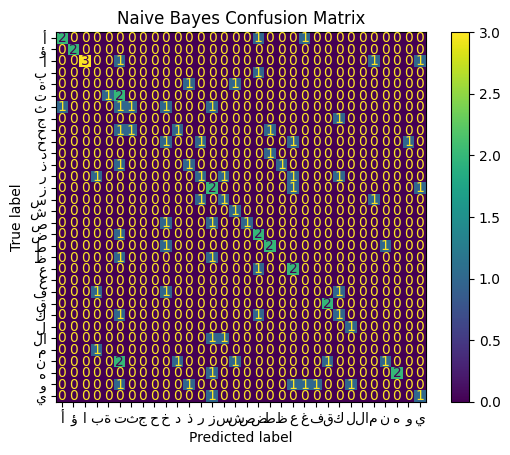

In [45]:
y_pred = clf.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Naive Bayes Confusion Matrix')
plt.show()

In [47]:
ffff = df_sampled1['qafiyeh'].astype('category').cat.codes

In [56]:
# After creating codes
# ffff = df_sampled1['qafiyeh'].astype('category').cat.codes

# Get the categories (the original values)
categories = df_sampled1['qafiyeh'].astype('category').cat.categories
print(categories)
# print(categories[ffff[0]])  # Get original value for first code

Index(['أ', 'ؤ', 'ا', 'ب', 'ة', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز',
       'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ف', 'ق', 'ك', 'ل', 'لا', 'م',
       'ن', 'ه', 'و', 'ي'],
      dtype='object')


In [57]:
indexes = ['أ', 'ؤ', 'ا', 'ب', 'ة', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز',
       'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ف', 'ق', 'ك', 'ل', 'لا', 'م',
       'ن', 'ه', 'و', 'ي']

In [51]:
# ====================================================
# FINE-TUNING WITH VALIDATION - SIMPLE VERSION
# ====================================================

# 1. Install
# !pip install -q transformers datasets pandas sklearn

# 2. Imports
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 3. Your Data
texts = df_sampled1["verses"]  # 100 samples

labels = ffff

# 4. Split into train and validation (80/20)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, 
    test_size=0.2,  # 20% for validation
    random_state=42,  # For reproducibility
    stratify=labels  # Maintain class distribution
)

print(f"Train samples: {len(train_texts)}")
print(f"Validation samples: {len(val_texts)}")

# 5. Create datasets
train_dataset = Dataset.from_dict({"text": train_texts, "label": train_labels})
val_dataset = Dataset.from_dict({"text": val_texts, "label": val_labels})

# 6. Load tokenizer and model
model_name = "../../pre_trained_models/marbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Fix padding token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=len(set(labels))
)

# 7. Tokenize function
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Tokenize both datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

# Remove text column
train_dataset = train_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])

# 8. Define metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro'),
        'f1_weighted': f1_score(labels, predictions, average='weighted'),
    }

# 9. Training arguments with validation
training_args = TrainingArguments(
    output_dir="../../models/poetry_classification_models/classify_by_qafyeh/arapoems_dataset_fine_tuneing_marbert_qafyeh_classification",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,  # Batch size for validation
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    evaluation_strategy="epoch",  # Evaluate at the end of each epoch
    save_strategy="epoch",         # Save at each epoch
    load_best_model_at_end=True,   # Load the best model when finished
    metric_for_best_model="f1_macro",  # Which metric to use for best model
    greater_is_better=True,         # Higher F1 is better
    save_total_limit=2,             # Keep only 2 best models
)

# 10. Create trainer with validation dataset
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,  # Add validation dataset
    compute_metrics=compute_metrics,
)

# 11. Train
# print("Starting training...")
# trainer.train()

# # 12. Final evaluation
# print("\n" + "="*50)
# print("FINAL VALIDATION RESULTS")
# print("="*50)
# eval_results = trainer.evaluate()
# for key, value in eval_results.items():
#     print(f"{key}: {value:.4f}")

Train samples: 743
Validation samples: 186


Some weights of the model checkpoint at ../../pre_trained_models/marbert were not used when initializing BertForSequenceClassification: ['cls.seq_relationship.bias', 'cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.decoder.weight']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the mode

In [52]:
trainer.train()

# 12. Final evaluation
print("\n" + "="*50)
print("FINAL VALIDATION RESULTS")
print("="*50)
eval_results = trainer.evaluate()
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")

/home/hussam/python_envs/complete_venv/lib/python3.10/site-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
2026/04/11 23:57:30 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/11 23:57:30 INFO mlflow.store.db.utils: Updating database tables
2026/04/11 23:57:30 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/04/11 23:57:30 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/04/11 23:57:30 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2026/04/11 23:57:30 INFO alembic.runtime.migration: Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
2026/04/11 23:57:30 INFO alembic.runtime.migration: Running upgrade 90e64c465722 -> 181f10493468, allow nul

{'loss': 3.4716, 'learning_rate': 5e-06, 'epoch': 0.11}


  5%|▍         | 21/465 [00:02<00:59,  7.44it/s]

{'loss': 3.4762, 'learning_rate': 1e-05, 'epoch': 0.22}


  6%|▋         | 30/465 [00:04<01:58,  3.66it/s]

...

{'eval_loss': 1.1386268138885498, 'eval_accuracy': 0.7849462365591398, 'eval_f1_macro': 0.7829696345321345, 'eval_f1_weighted': 0.7867213431729561, 'eval_runtime': 2.3161, 'eval_samples_per_second': 80.309, 'eval_steps_per_second': 10.362, 'epoch': 5.0}


100%|██████████| 465/465 [02:15<00:00,  3.44it/s]


{'train_runtime': 136.0273, 'train_samples_per_second': 27.311, 'train_steps_per_second': 3.418, 'train_loss': 1.8880281002290786, 'epoch': 5.0}

FINAL VALIDATION RESULTS


100%|██████████| 24/24 [00:00<00:00, 35.70it/s]

eval_loss: 1.1386
eval_accuracy: 0.7849
eval_f1_macro: 0.7830
eval_f1_weighted: 0.7867
eval_runtime: 0.6716
eval_samples_per_second: 276.9680
eval_steps_per_second: 35.7380
epoch: 5.0000


In [ ]:
# trainer.save_model("../../models/poetry_classification_models/classify_by_qafyeh/arapoems_dataset_arapoembert_fine_tuning_qafyeh_classification/best")
# tokenizer.save_pretrained("../../models/poetry_classification_models/classify_by_qafyeh/arapoems_dataset_arapoembert_fine_tuning_qafyeh_classification/best")

('../../models/poetry_classification_models/classify_by_qafyeh/arapoems_dataset_arapoembert_fine_tuning_qafyeh_classification/best/tokenizer_config.json',
 '../../models/poetry_classification_models/classify_by_qafyeh/arapoems_dataset_arapoembert_fine_tuning_qafyeh_classification/best/special_tokens_map.json',
 '../../models/poetry_classification_models/classify_by_qafyeh/arapoems_dataset_arapoembert_fine_tuning_qafyeh_classification/best/vocab.txt',
 '../../models/poetry_classification_models/classify_by_qafyeh/arapoems_dataset_arapoembert_fine_tuning_qafyeh_classification/best/added_tokens.json',
 '../../models/poetry_classification_models/classify_by_qafyeh/arapoems_dataset_arapoembert_fine_tuning_qafyeh_classification/best/tokenizer.json')